In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("train.csv")
print("First 5 Rows:")
print(df.head())

print("Missing Values Before Handling:")
print(df.isnull().sum())




First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

### Handling Missing Values

I used fillna() instead of dropna() because dropping rows with missing values can reduce the size of the dataset and remove important information.
The missing values in Age were replaced using the median because age contains numerical data and median is less affected by extreme values.
The missing values in Embarked were replaced using the mode because it is a categorical feature.

In [8]:
# Filling Age missing values with median

df['Age'] = df['Age'].fillna(df['Age'].median())


# Filling Embarked missing values with mode

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


print("Missing Values After Handling:")

print(df.isnull().sum())

Missing Values After Handling:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


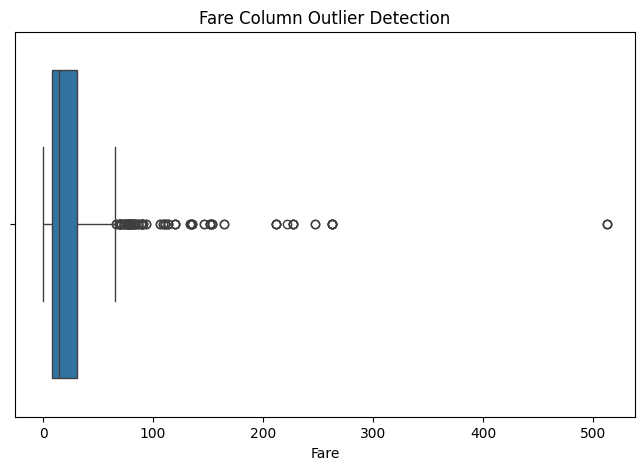

In [9]:
#Detect Outliers Using Boxplot
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Fare'])

plt.title("Fare Column Outlier Detection")

plt.xlabel("Fare")

plt.show()

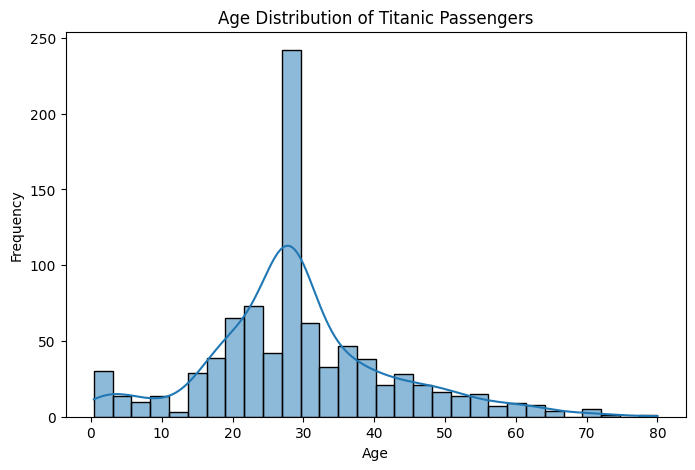

In [10]:
#Visualization 1 — Histogram
#(Age Distribution)
plt.figure(figsize=(8,5))
sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)
plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

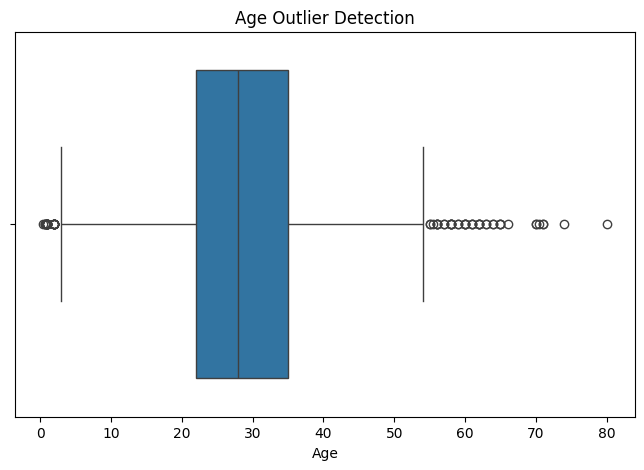

In [11]:
#Visualization 2 — Boxplot
#(Age Outliers)
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Age']
)
plt.title("Age Outlier Detection")
plt.xlabel("Age")
plt.show()

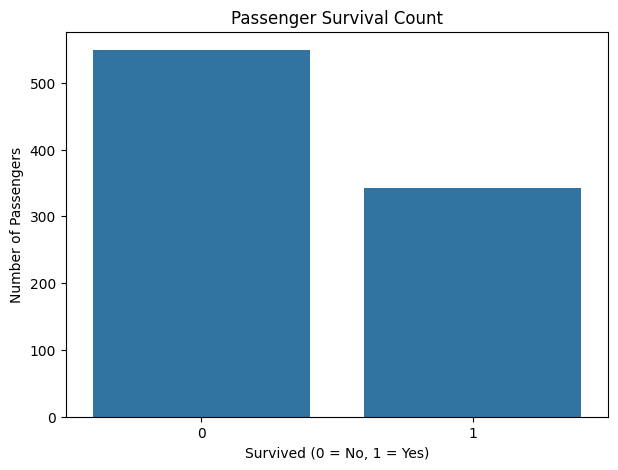

In [12]:
#Visualization 3 — Bar Chart
#Survival Count
plt.figure(figsize=(7,5))
sns.countplot(
    x="Survived",
    data=df
)
plt.title("Passenger Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

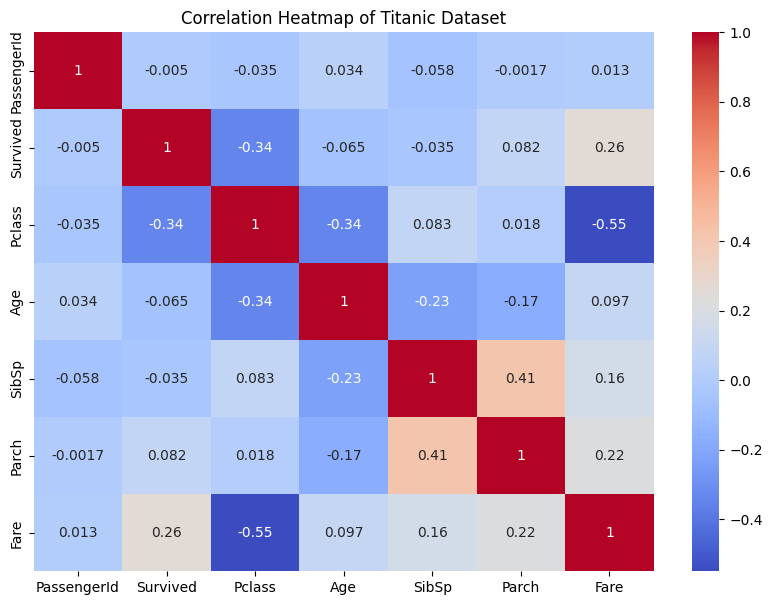

In [13]:
#Visualization 4 — Correlation Heatmap
plt.figure(figsize=(10,7))
numeric_df = df.select_dtypes(include=np.number)
correlation = numeric_df.corr()
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap of Titanic Dataset")
plt.show()

Feature Affecting Survival:
According to my analysis, the feature that most affects survival is Passenger Class (Pclass).
Passengers in first class had higher survival rates compared to second and third class passengers.
This indicates that social and economic status played an important role because first-class passengers had better access to safety resources during the disaster.



In [14]:
print("Survival Rate According to Passenger Class:")

print(
    df.groupby('Pclass')['Survived'].mean()
)

Survival Rate According to Passenger Class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
